In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib as plt
import warnings 
warnings.filterwarnings("ignore")

In [18]:
wlm_ibm = yf.download(tickers='wmt ibm', period='5y', interval='1d', rounding='True')
wlm_ibm

[*********************100%***********************]  2 of 2 completed


Price        Close            High             Low            Open          \
Ticker         IBM     WMT     IBM     WMT     IBM     WMT     IBM     WMT   
Date                                                                         
2021-03-29  106.41   42.65  107.35   42.76  106.13   42.01  106.50   42.13   
2021-03-30  105.51   42.36  106.73   42.94  104.96   42.28  106.41   42.55   
2021-03-31  104.37   42.39  105.50   42.71  103.94   42.12  105.37   42.30   
2021-04-01  104.35   42.33  104.89   42.72  103.59   42.24  104.76   42.43   
2021-04-05  106.46   43.52  107.06   43.74  104.48   42.51  104.67   42.67   
...            ...     ...     ...     ...     ...     ...     ...     ...   
2026-03-23  248.44  120.72  251.35  121.13  244.71  119.05  246.50  120.48   
2026-03-24  240.59  122.05  247.11  124.11  238.00  120.49  246.45  120.63   
2026-03-25  241.39  123.06  246.19  123.49  238.00  121.78  243.60  122.81   
2026-03-26  241.67  122.18  246.67  123.80  239.80  121.79  240.56  123.61   
2026-03-27  236.34  122.89  239.44  124.27  233.75  121.82  238.85  122.03   

Price        Volume            
Ticker          IBM       WMT  
Date                           
2021-03-29  4835344  30146400  
2021-03-30  5010758  27230100  
2021-03-31  5172575  24546000  
2021-04-01  4261404  25595100  
2021-04-05  5722980  40043100  
...             ...       ...  
2026-03-23  4972000  22181500  
2026-03-24  4151500  17269600  
2026-03-25  4207900  16597300  
2026-03-26  3606800  16442500  
2026-03-27  4848800  16537300  

[1256 rows x 10 columns]

In [20]:
wlm_ibm = wlm_ibm['Close']
wlm_ibm

Ticker,IBM,WMT
Date,,
2021-03-29,106.41,42.65
2021-03-30,105.51,42.36
2021-03-31,104.37,42.39
2021-04-01,104.35,42.33
2021-04-05,106.46,43.52
...,...,...
2026-03-23,248.44,120.72
2026-03-24,240.59,122.05
2026-03-25,241.39,123.06


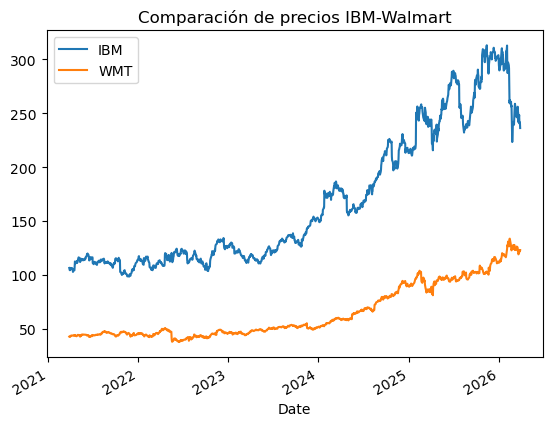

In [24]:
wlm_ibm['IBM'].plot().plot(label='IBM')
wlm_ibm['WMT'].plot().plot(label='Walmart')
plt.title('Comparación de precios IBM-Walmart')
plt.legend()
plt.show()

In [30]:
rend_wlm_ibm = wlm_ibm.pct_change().dropna()
rend_wlm_ibm

Ticker,IBM,WMT
Date,,
2021-03-30,-0.008458,-0.006800
2021-03-31,-0.010805,0.000708
2021-04-01,-0.000192,-0.001415
2021-04-05,0.020220,0.028112
2021-04-06,-0.012587,0.004596
...,...,...
2026-03-23,0.027588,0.014283
2026-03-24,-0.031597,0.011017
2026-03-25,0.003325,0.008275


In [32]:
correlacion = rend_wlm_ibm['IBM'].corr(rend_wlm_ibm['WMT'])
correlacion

0.18398977158467447

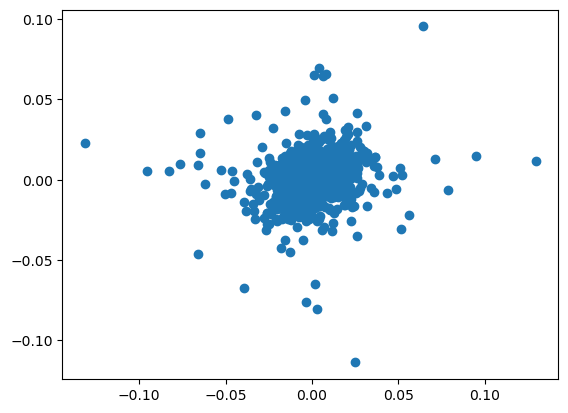

In [34]:
plt.scatter(rend_wlm_ibm['IBM'], rend_wlm_ibm['WMT'])
plt.show()

Un valor de 0.18 indica una correlación positiva extremadamente débil, casi inexistente.

Esto significa que, matemáticamente, lo que haga la acción de IBM en un día cualquiera no te sirve casi de nada para predecir lo que hará la acción de Walmart ese mismo día. Sus movimientos son en gran medida independientes.

In [37]:
import statsmodels.api as sm
rend_wlm_ibm = sm.add_constant(rend_wlm_ibm)
rend_wlm_ibm

,const,IBM,WMT
Date,,,
2021-03-30,1.0,-0.008458,-0.006800
2021-03-31,1.0,-0.010805,0.000708
2021-04-01,1.0,-0.000192,-0.001415
2021-04-05,1.0,0.020220,0.028112
2021-04-06,1.0,-0.012587,0.004596
...,...,...,...
2026-03-23,1.0,0.027588,0.014283
2026-03-24,1.0,-0.031597,0.011017
2026-03-25,1.0,0.003325,0.008275


In [39]:
regresion = sm.OLS(rend_wlm_ibm['IBM'], rend_wlm_ibm[['const', 'WMT']]).fit()
print(regresion.summary())

                            OLS Regression Results                            
Dep. Variable:                    IBM   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     43.90
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           5.11e-11
Time:                        21:55:01   Log-Likelihood:                 3452.6
No. Observations:                1255   AIC:                            -6901.
Df Residuals:                    1253   BIC:                            -6891.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.273      0.2

[*********************100%***********************]  1 of 1 completed


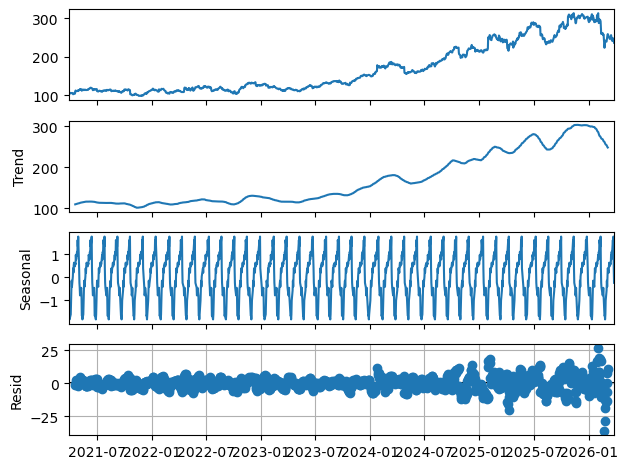

In [45]:
ibm = yf.download(tickers='ibm', period='5y', interval='1d', rounding='True')
ibm = ibm['Close']
decomposed_ibm = sm.tsa.seasonal_decompose(ibm,period=30)
figure = decomposed_ibm.plot()
plt.grid()
plt.show()

[*********************100%***********************]  1 of 1 completed


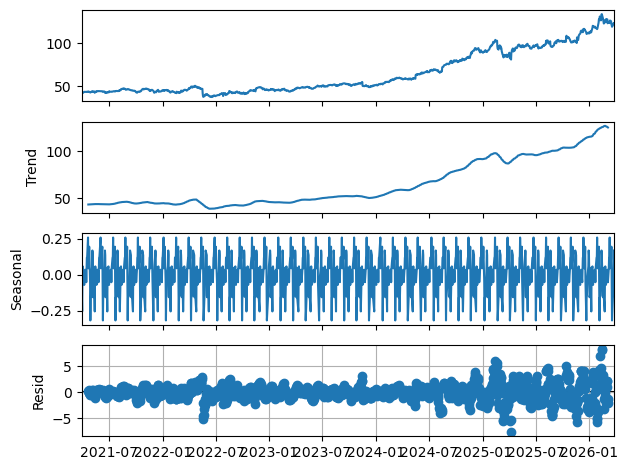

In [47]:
wmt = yf.download(tickers='wmt', period='5y', interval='1d', rounding='True')
wmt = wmt['Close']
decomposed_wmt = sm.tsa.seasonal_decompose(wmt,period=30)
figure = decomposed_wmt.plot()
plt.grid()
plt.show()

Se observa como IBM tiene una tendencia alcista agresiva, una estacionalidad clara con brincos que van de +1.5 a -1.5 dólares. Mientras que Walmart su tendencia es una rampa casi perfecta y suave, sin estacionalidad. Ambas presentan heterocedasticidad cuando llegas a 2026 y 2026. Haciendo que IBM se vuelva un activo inestable mientras que Walmart un activo seguro.

In [50]:
from statsmodels.tsa.stattools import adfuller

# 1. Prueba Dickey-Fuller para IBM
adf_ibm = adfuller(rend_wlm_ibm['IBM'].dropna())
print(f"El p-value de IBM es: {adf_ibm[1]:.5f}")

# 2. Prueba Dickey-Fuller para Walmart
adf_wmt = adfuller(rend_wlm_ibm['WMT'].dropna())
print(f"El p-value de Walmart es: {adf_wmt[1]:.5f}")

El p-value de IBM es: 0.00000
El p-value de Walmart es: 0.00000


Al correr la prueba de Dickey-Fuller para ambas series despues de aplicar .pct_change(), cambiamos los datos crudos por porcentajes de ganancia o pérdida diaria, siendo que estos datos no son estacionarios.

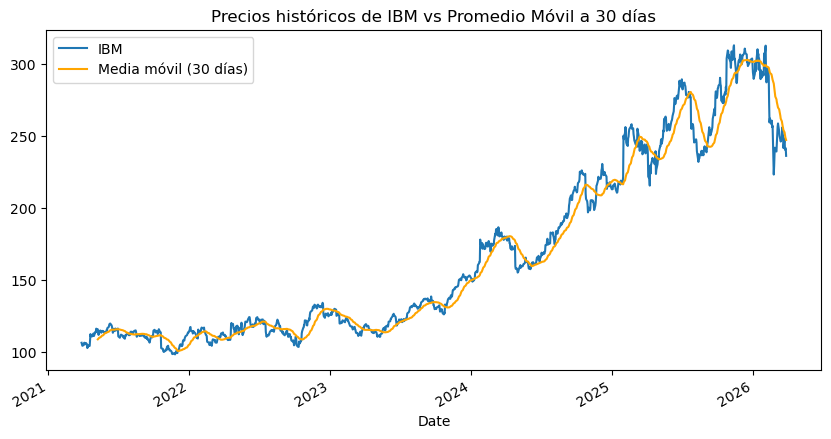

In [60]:
rollin_ibm = ibm.rolling(30).mean()
ax = ibm.plot(figsize=(10,5), label="IBM")
rollin_ibm.plot(ax=ax, label="Media móvil (30 días)", color='orange')

plt.title("Precios históricos de IBM vs Promedio Móvil a 30 días")
plt.legend(["IBM", "Media móvil (30 días)"])
plt.show()

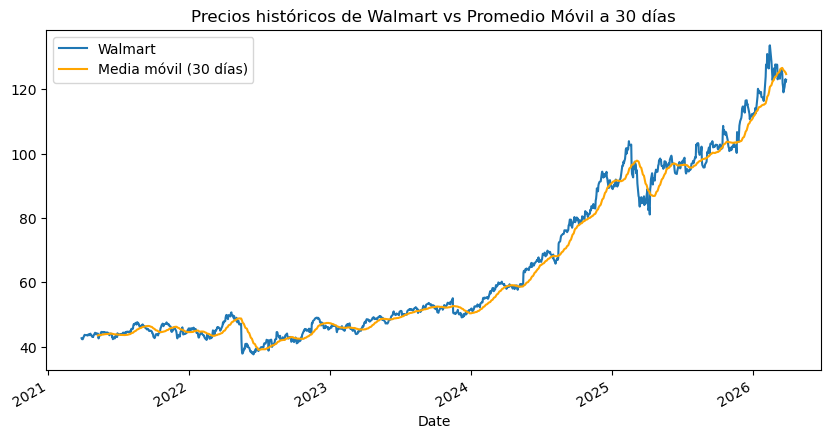

In [62]:
rollin_wmt = wmt.rolling(30).mean()
ax = wmt.plot(figsize=(10,5), label="Walmart")
rollin_wmt.plot(ax=ax, label="Media móvil (30 días)", color='orange')

plt.title("Precios históricos de Walmart vs Promedio Móvil a 30 días")
plt.legend(["Walmart", "Media móvil (30 días)"])
plt.show()

In [65]:
#Prediccion simple mediante promedios moviles IBM
ibm.shape

(1256, 1)

In [67]:
len_train = int(1256*0.7)
len_train

879

In [71]:
train = ibm[0:len_train]
test = ibm[len_train:]

In [75]:
y_pred_ibm = ibm.copy()
y_pred_ibm = pd.DataFrame(y_pred_ibm)

In [77]:
y_pred_ibm['pronostico'] = ibm.rolling(30).mean()
y_pred_ibm[0:35]

Ticker,IBM,pronostico
Date,,
2021-03-29,106.41,NaN
2021-03-30,105.51,NaN
2021-03-31,104.37,NaN
2021-04-01,104.35,NaN
2021-04-05,106.46,NaN
2021-04-06,105.12,NaN
2021-04-07,105.68,NaN
2021-04-08,105.83,NaN
2021-04-09,106.30,NaN


In [105]:
y_pred_modibm = pd.DataFrame(y_pred_modibm['pronostico'][880:])
y_pred_modibm

,pronostico
Date,
2024-09-26,198.168
2024-09-27,199.03
2024-09-30,199.905
2024-10-01,200.694333
2024-10-02,201.454333
...,...
2026-03-23,252.670333
2026-03-24,250.868
2026-03-25,249.189


In [93]:
y_pred_modibm = y_pred_ibm.copy()
y_pred_modibm['pronostico'][29] = 'NaN'
for contador in range(30,879):
    y_pred_modibm['pronostico'][contador]=y_pred_ibm['pronostico'][contador-1]
y_pred_modibm[0:35]

Ticker,IBM,pronostico
Date,,
2021-03-29,106.41,NaN
2021-03-30,105.51,NaN
2021-03-31,104.37,NaN
2021-04-01,104.35,NaN
2021-04-05,106.46,NaN
2021-04-06,105.12,NaN
2021-04-07,105.68,NaN
2021-04-08,105.83,NaN
2021-04-09,106.30,NaN


In [85]:
test=pd.DataFrame(test)
frames = [test,y_pred_modibm]
result = pd.concat(frames, axis=1,join='inner')
result.columns = ['Observado', 'Pronosticado']

Ticker,IBM
Date,
2024-09-25,212.76
2024-09-26,214.87
2024-09-27,212.38
2024-09-30,212.61
2024-10-01,210.95
...,...
2026-03-23,248.44
2026-03-24,240.59
2026-03-25,241.39


In [107]:
from sklearn.metrics import mean_squared_error
test_alineado_ibm = test[-len(y_pred_modibm):]
rmse = np.sqrt(mean_squared_error(test_alineado_ibm, y_pred_modibm)).round(2)
print(f"El margen de error (RMSE) de tu modelo es: ${rmse} dólares")

El margen de error (RMSE) de tu modelo es: $15.91 dólares


In [109]:
from sklearn.metrics import mean_absolute_percentage_error
mape_pro = mean_absolute_percentage_error(test_alineado_ibm, y_pred_modibm) * 100
print(f"El Error Porcentual (MAPE) oficial es: {mape_pro.round(2)}%")

El Error Porcentual (MAPE) oficial es: 5.01%


In [113]:
y_pred_ibm.tail(1)['pronostico']

Date
2026-03-27    247.378333
Name: pronostico, dtype: float64

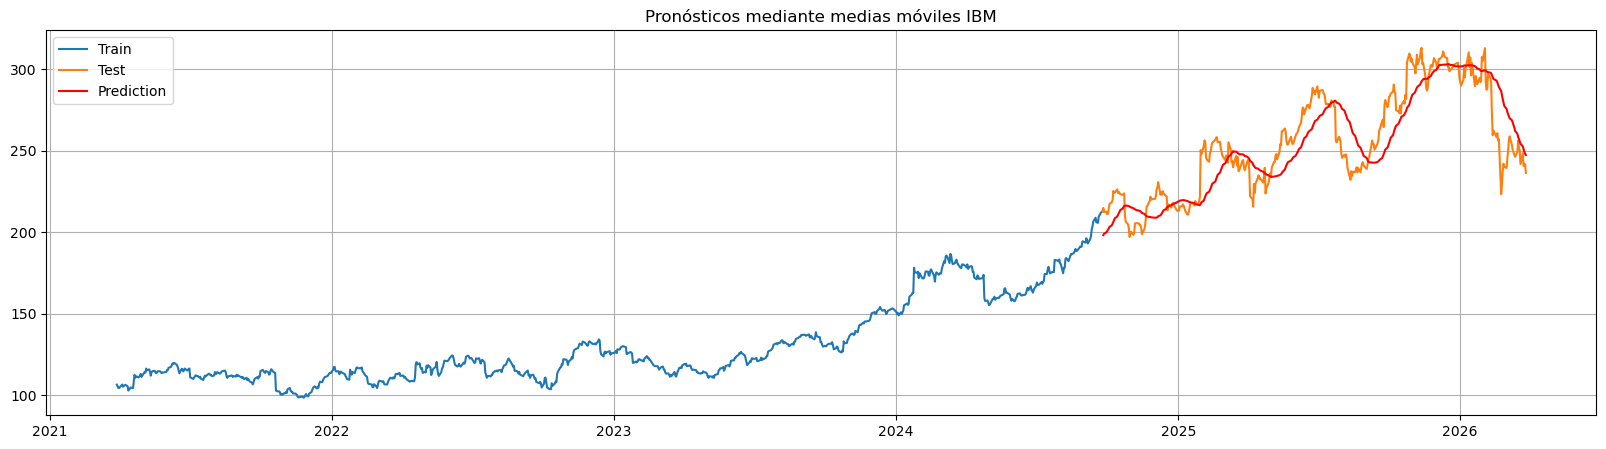

In [115]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(y_pred_modibm['pronostico'], label='Prediction', color='red')
plt.legend(loc='best')
plt.title('Pronósticos mediante medias móviles IBM')
plt.show()

In [197]:
#Prediccion simple mediante promedios moviles WMT
wmt.shape

(1256, 1)

In [199]:
train_wmt = wmt[0:len_train]
test_wmt = wmt[len_train:]

In [247]:
y_pred_wmt = wmt.copy()
y_pred_wmt = pd.DataFrame(y_pred_wmt)

In [249]:
y_pred_wmt['pronostico'] = wmt.rolling(30).mean()
y_pred_wmt[0:35]

Ticker,WMT,pronostico
Date,,
2021-03-29,42.65,NaN
2021-03-30,42.36,NaN
2021-03-31,42.39,NaN
2021-04-01,42.33,NaN
2021-04-05,43.52,NaN
2021-04-06,43.72,NaN
2021-04-07,43.63,NaN
2021-04-08,43.60,NaN
2021-04-09,43.62,NaN


In [243]:
y_pred_wmt = pd.DataFrame(y_pred_wmt['pronostico'][880:])
y_pred_wmt

,pronostico
Date,
2024-09-26,76.404667
2024-09-27,76.628667
2024-09-30,76.868667
2024-10-01,77.117000
2024-10-02,77.310667
...,...
2026-03-23,125.580667
2026-03-24,125.357000
2026-03-25,125.244333


In [251]:
y_pred_modwmt = y_pred_wmt.copy()
y_pred_modwmt['pronostico'][29] = 'NaN'
for contador in range(30,879):
    y_pred_modwmt['pronostico'][contador]=y_pred_wmt['pronostico'][contador-1]
y_pred_modwmt[0:35]

Ticker,WMT,pronostico
Date,,
2021-03-29,42.65,NaN
2021-03-30,42.36,NaN
2021-03-31,42.39,NaN
2021-04-01,42.33,NaN
2021-04-05,43.52,NaN
2021-04-06,43.72,NaN
2021-04-07,43.63,NaN
2021-04-08,43.60,NaN
2021-04-09,43.62,NaN


In [253]:
test_wmt=pd.DataFrame(test_wmt)
frames_wmt = [test_wmt,y_pred_modwmt['pronostico']]
result_wmt = pd.concat(frames_wmt, axis=1,join='inner')
result_wmt.columns = ['Observado', 'Pronosticado']

In [263]:
predicciones_finales = y_pred_modwmt['pronostico'][880:]
test_alineado_wmt = test_wmt[-len(predicciones_finales):]
rmse_wmt = np.sqrt(mean_squared_error(test_alineado_wmt, predicciones_finales)).round(2)
print(f"El margen de error (RMSE) de tu modelo para Walmart es: ${rmse_wmt} dólares")

El margen de error (RMSE) de tu modelo para Walmart es: $4.6 dólares


In [265]:
mape_pro = mean_absolute_percentage_error(test_alineado_wmt, predicciones_finales) * 100
print(f"El Error Porcentual (MAPE) oficial es: {mape_pro.round(2)}%")

El Error Porcentual (MAPE) oficial es: 3.54%


In [267]:
y_pred_wmt.tail(1)['pronostico']

Date
2026-03-27    124.684
Name: pronostico, dtype: float64

In [271]:
import numpy as np
matriz_cov = rend_wlm_ibm.cov() * 252
var_ibm = matriz_cov.loc['IBM', 'IBM']
var_wmt = matriz_cov.loc['WMT', 'WMT']
cov_ibm_wmt = matriz_cov.loc['IBM', 'WMT']


peso_ibm = (var_wmt - cov_ibm_wmt) / (var_ibm + var_wmt - 2 * cov_ibm_wmt)
peso_wmt = 1 - peso_ibm

print("--- PESOS ÓPTIMOS DEL PORTAFOLIO DE VARIANZA MÍNIMA ---")
print(f"Porcentaje de capital para IBM: {np.round(peso_ibm * 100, 2)}%")
print(f"Porcentaje de capital para Walmart (El Escudo): {np.round(peso_wmt * 100, 2)}%")

--- PESOS ÓPTIMOS DEL PORTAFOLIO DE VARIANZA MÍNIMA ---
Porcentaje de capital para IBM (El Motor): 39.79%
Porcentaje de capital para Walmart (El Escudo): 60.21%
